[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rafelsalgueiro/GallegoSalgueiroVera/blob/main/k_brazos/estudio_bernoulli.ipynb)

# Estudio completo del problema de k-armed bandit con brazos Bernoulli

**Descripción:** Este notebook realiza un estudio exhaustivo del problema de k-armed bandit
utilizando brazos con distribución de Bernoulli. Se comparan los siguientes algoritmos:

- **Epsilon-Greedy** (con distintos valores de ε)
- **UCB1** (con distintos valores de c)
- **Softmax** (con distintas temperaturas τ)

Se analizan métricas de **regret acumulado** y **porcentaje de selección óptima**, y se incluye
un experimento final de **comparación directa** entre los tres algoritmos.

### El Problema Multi-Armed Bandit

El problema consiste en un agente que debe elegir repetidamente entre $k$ opciones (brazos). Cada opción proporciona una recompensa extraída de una distribución de probabilidad desconocida para esa opción. El objetivo es maximizar la recompensa total (o minimizar el *regret* acumulado) a lo largo de un horizonte temporal $T$.

En este caso, usamos **brazos de Bernoulli**, donde la recompensa es 1 con probabilidad $p$ y 0 con probabilidad $1-p$. El valor esperado de un brazo es simplemente su probabilidad de éxito $p$.

    Authors: Gallego, Salgueiro y Vera.
    Date: 2026/02/16


## 1. Preparación del entorno

A continuación están todos los requisitos Python para este estudio, importándose las librerías necesarias.

In [ ]:
!git clone https://github.com/rafelsalgueiro/GallegoSalgueiroVera.git

In [ ]:
!pip install matplotlib numpy seaborn

In [ ]:
!cd GallegoSalgueiroVera/k_brazos && pwd

In [4]:
import sys
import os

import numpy as np
import matplotlib.pyplot as plt

project_root = os.path.abspath('GallegoSalgueiroVera/k_brazos')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

try:
    from src.agents import *
    from src.arms import BernoulliArm, Bandit
    from src.plotting import *
    print("Entorno cargado correctamente.")

except ImportError as e:
    print(f"Error cargando el entorno: {e}")
    sys.exit(1)
    
# Parámetros del experimento
seed = 42
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

Entorno cargado correctamente.


## 2. Definición del bucle experimental

La función `run_experiment` ejecuta cada algoritmo sobre el mismo conjunto de brazos Bernoulli
durante `n_steps` pasos, repitiendo el proceso `n_runs` veces para obtener resultados promediados.

Se calculan dos métricas:
- **Regret acumulado:** diferencia acumulada entre la recompensa esperada del brazo óptimo y la del brazo seleccionado.
- **Selección óptima:** proporción de veces que se selecciona el brazo con mayor valor esperado.

In [5]:
def run_experiment(bandit: Bandit, agents: list[Agent], steps: int, runs: int):
    """Ejecuta el experimento de multi-armed bandit.

    Args:
        bandit (Bandit): El entorno del bandit.
        agents (list[Agent]): Lista de agentes a evaluar.
        steps (int): Número de pasos por ejecución.
        runs (int): Número de ejecuciones para promediar resultados.

    Returns:
        rewards (np.ndarray): Matriz de recompensas promedio por agente y paso.
        optimal_selections (np.ndarray): Matriz de selecciones óptimas por agente y paso.
    """
    optimal_arm_idx, _ = bandit.get_optimal_arm()
    rewards = np.zeros((len(agents), steps))
    optimal_selections = np.zeros((len(agents), steps))

    for run in range(runs):
        current_bandit = Bandit(bandit.arms)
        for agent in agents:
            agent.reset()

        for step in range(steps):
            for idx, agent in enumerate(agents):
                action = agent.get_action()
                reward = current_bandit.pull_arm(action)
                agent.update(action, reward)

                rewards[idx, step] += reward

                if action == optimal_arm_idx:
                    optimal_selections[idx, step] += 1
            
    rewards /= runs
    optimal_selections /= runs
    return rewards, optimal_selections

## 3. Configuración de los brazos Bernoulli

Definimos un bandido de 5 brazos con distintas probabilidades de éxito.
El brazo con `p = 0.9` es el óptimo.

In [6]:
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones
k = 5 # Número de brazos

# Creación del bandit
bandit = Bandit(arms=[
    BernoulliArm(0.1),
    BernoulliArm(0.3),
    BernoulliArm(0.5),
    BernoulliArm(0.7),
    BernoulliArm(0.9),
])

# Constante teórica de Lai-Robbins para la cota inferior del regret
lai_robbins_cte = bandit.get_theoretical_constant()

def show_bandit_info(bandit: Bandit, title: str):
    print(f"--- {title} ---")
    print(bandit)
    optimal_arm_idx, optimal_value = bandit.optimal_arm
    print(f"Brazo óptimo: {optimal_arm_idx} con media {optimal_value:.4f}")
    print(f"Constante de Lai-Robbins: {bandit.get_theoretical_constant():.4f}")

show_bandit_info(bandit, "Bandit Bernoulli")

--- Bandit Bernoulli ---
Bandit with 5 arms: ArmBernoulli(p=0.1), ArmBernoulli(p=0.3), ArmBernoulli(p=0.5), ArmBernoulli(p=0.7), ArmBernoulli(p=0.9)
Brazo óptimo: 4 con media 0.9000
Constante de Lai-Robbins: 3.1208


---
## 4. Epsilon-Greedy con distintos valores de ε

### Teoría: Epsilon-Greedy

El algoritmo Epsilon-Greedy es una de las estrategias más simples para equilibrar exploración y explotación:

- Con probabilidad $1-\epsilon$, explotamos: elegimos el brazo con mayor valor estimado promedio hasta el momento.
- Con probabilidad $\epsilon$, exploramos: elegimos un brazo aleatorio uniformemente.

El parámetro $\epsilon$ controla este balance. Un $\epsilon$ alto favorece el descubrimiento rápido pero impide converger completamente al óptimo. Un $\epsilon$ bajo es más eficiente a largo plazo pero lento al inicio.



Comparamos tres configuraciones del algoritmo Epsilon-Greedy:
- `ε = 0.0` (puramente voraz, sin exploración)
- `ε = 0.01` (exploración mínima)
- `ε = 0.1` (exploración moderada)
- `ε = 0.3` (exploración alta)

In [7]:
# Definir agentes Epsilon-Greedy con distintos epsilon
agents_e = [
    EpsilonGreedyAgent(k, epsilon=0.0),
    EpsilonGreedyAgent(k, epsilon=0.01),
    EpsilonGreedyAgent(k, epsilon=0.1),
    EpsilonGreedyAgent(k, epsilon=0.3),
]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards_e, optimal_selections_e = run_experiment(bandit, agents_e, steps, runs)

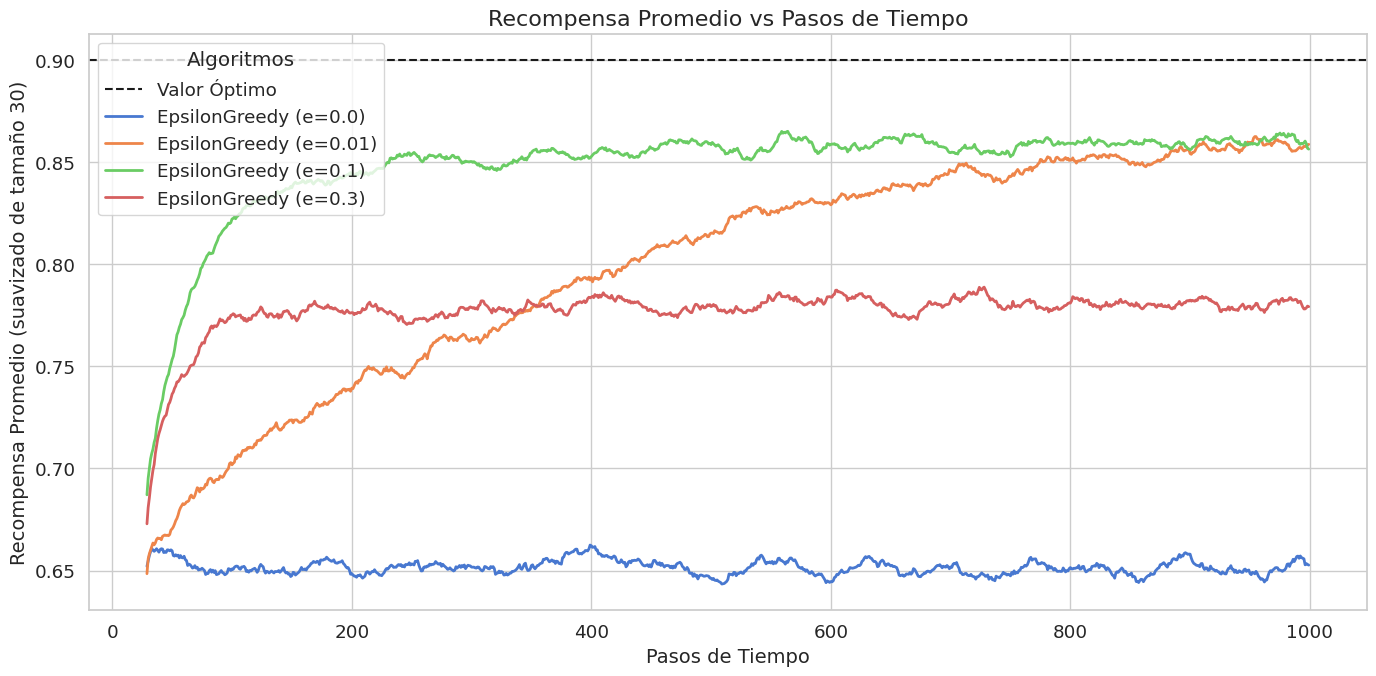

In [8]:
_, optimal_value = bandit.optimal_arm
plot_average_rewards(steps, rewards_e, agents_e, optimal_value=optimal_value, window_size=30)

Véase como en la gráfica de recompensa promedio se puede observar la influencia del parámetro epsilon en la política de exploración. Un epsilon nulo provoca que el agente se quede con la primera estimación, sin corregir posibles errores. Un epsilon de $0.1$ es el que alcanza la mayor recompensa promedio, equilibrando exploración y explotación. Un epsilon de $0.3$ crece rápido al inicio pero se estabiliza por debajo del óptimo al explorar continuamente.

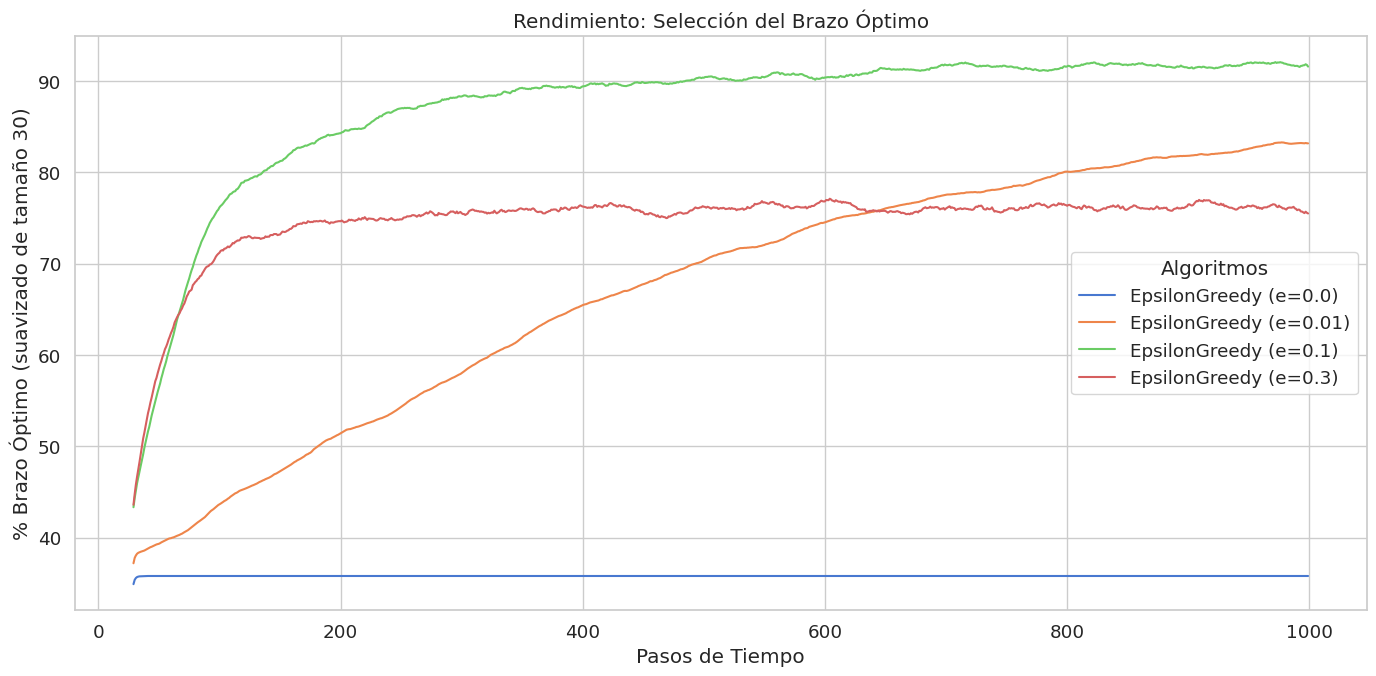

In [9]:
# Gráfica de selección óptima para Epsilon-Greedy
plot_optimal_selections(steps, optimal_selections_e, agents_e, window_size=30)

Respecto a la convergencia sobre la selección del brazo óptimo, nuevamente el valor epsilon $0.1$ es el que produce el mayor porcentaje de aciertos. Véase que un épsilo muy pequeño tiene un ritmo de convergencia mucho más bajo, lo que se debe a que el algoritmo tiende a explotar más los brazos que conoce ya con mayor valor esperado. Por otro lado, véase que aumentarlo demasiado provoca que se explore demasiado, impidiendo que se seleccionen en la mayoria de ocasiones el brazo óptimo. Véase que el experimento con epsilon $0.3$, si bien se estabiliza más o menos al mismo tiempo que el experimento con epsilon $0.1$, lo hace en un valor de acierto sobre el brazo óptimo bastante más bajo.

Finalmente, calculamos el arrepentimiento acumulado y lo representamos junto a la cota teórica de Lai-Robbins:

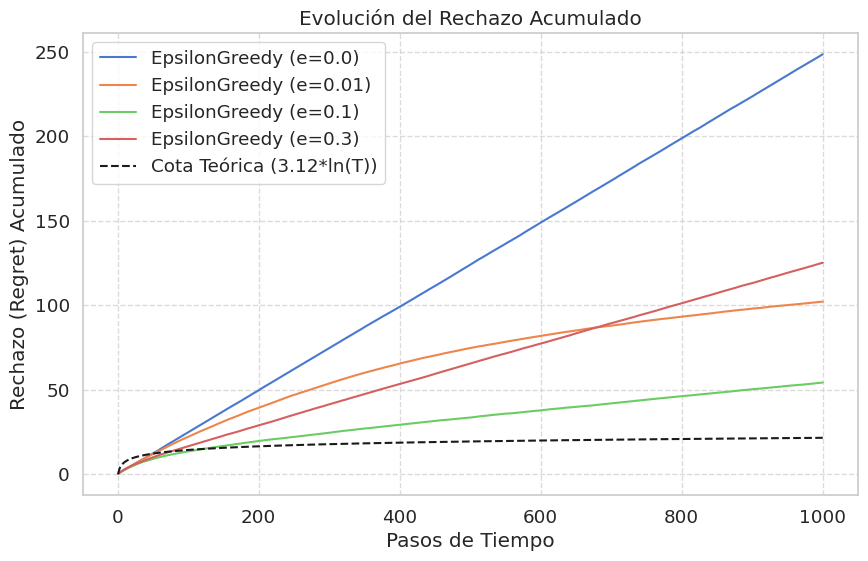

In [10]:
_, optimal_value = bandit.optimal_arm
regret_per_step = optimal_value - rewards_e
cumulative_regret = np.cumsum(regret_per_step, axis=1)

plot_regret(steps, cumulative_regret, agents_e, cte=lai_robbins_cte)

### Análisis de Resultados (Epsilon-Greedy)

Observamos los siguientes comportamientos característicos:

1. **Greedy ($\epsilon=0$):** Se estanca rápidamente. Si tiene suerte al principio, funciona muy bien, pero frecuentemente converge a un brazo subóptimo y se queda allí para siempre. Su curva de selección óptima suele ser plana y baja.
2. **$\epsilon=0.1$:** Suele ofrecer el mejor compromiso. Aprende rápidamente cuál es el mejor brazo y lo explota la mayoría del tiempo. Sin embargo, nótese que su curva de regret sigue creciendo linealmente, ya que siempre explora el 10% del tiempo.
3. **$\epsilon=0.3$:** Aprende muy rápido (subida inicial pronunciada en selección óptima), pero su techo es bajo (máximo 70% de selección óptima teórica) porque pasa demasiado tiempo explorando aleatoriamente.
4. **$\epsilon=0.01$:** Converge muy lentamente. Tarda mucho en encontrar el óptimo, pero a muy largo plazo podría superar a $\epsilon=0.1$ en selección óptima acumulada.

---
## 5. UCB1 con distintos valores de c

### Teoría: UCB1 (Upper Confidence Bound)

UCB1 sigue el principio de "optimismo ante la incertidumbre". En lugar de usar una aleatoriedad fija como Epsilon-Greedy, UCB1 calcula un índice de confianza para cada brazo y elige el que tiene el límite superior más alto:

$$ A_t = \arg\max_a \left[ Q_t(a) + c \sqrt{\frac{\ln t}{N_t(a)}} \right] $$

- El primer término $Q_t(a)$ fomenta la explotación (brazos con buen promedio).
- El segundo término fomenta la exploración de brazos poco visitados (donde $N_t(a)$ es pequeño).
- A medida que el tiempo $t$ avanza, el término de exploración decrece, permitiendo que el algoritmo converja naturalmente al brazo óptimo sin necesidad de reducir un parámetro manualmente.

El parámetro `c` controla el grado de exploración en la fórmula UCB1:

$$Q(a) + c \cdot \sqrt{\frac{\ln(t)}{N(a)}}$$

Comparamos:
- `c = 0.5` (exploración conservadora)
- `c = 1.0` (exploración moderada)
- `c = 2.0` (exploración estándar)
- `c = 4.0` (exploración agresiva)

In [11]:
# Definir agentes UCB1 con distintos parámetros c
agents_ucb = [
    UCBAgent(k_arms=k, c=0.5),
    UCBAgent(k_arms=k, c=1.0),
    UCBAgent(k_arms=k, c=2.0),
    UCBAgent(k_arms=k, c=4.0),
]

rewards_ucb, optimal_selections_ucb = run_experiment(bandit, agents_ucb, steps, runs)

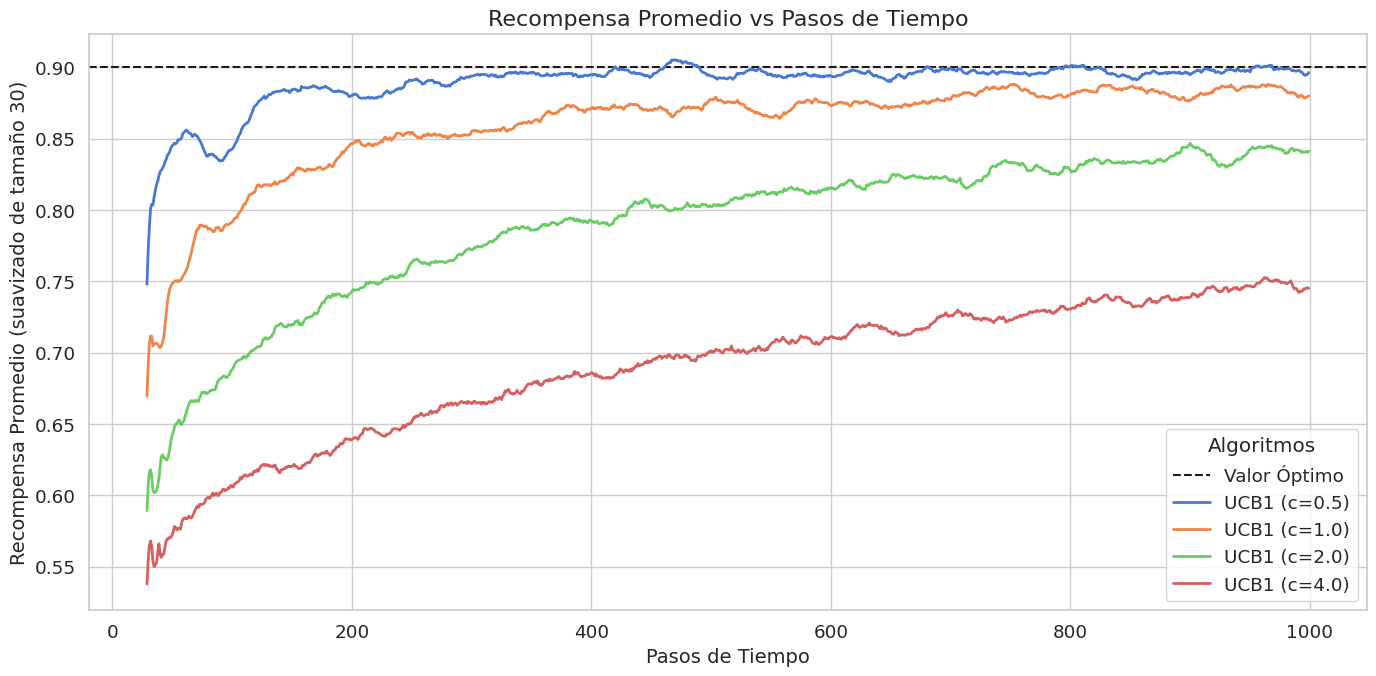

In [12]:
_, optimal_value = bandit.optimal_arm
plot_average_rewards(steps, rewards_ucb, agents_ucb, optimal_value=optimal_value, window_size=30)

Véase cómo UCB1 con $c=0.5$ alcanza rápidamente recompensas cercanas al óptimo. Valores altos de $c$ (como 4.0) provocan demasiada exploración inicial, ralentizando la convergencia.

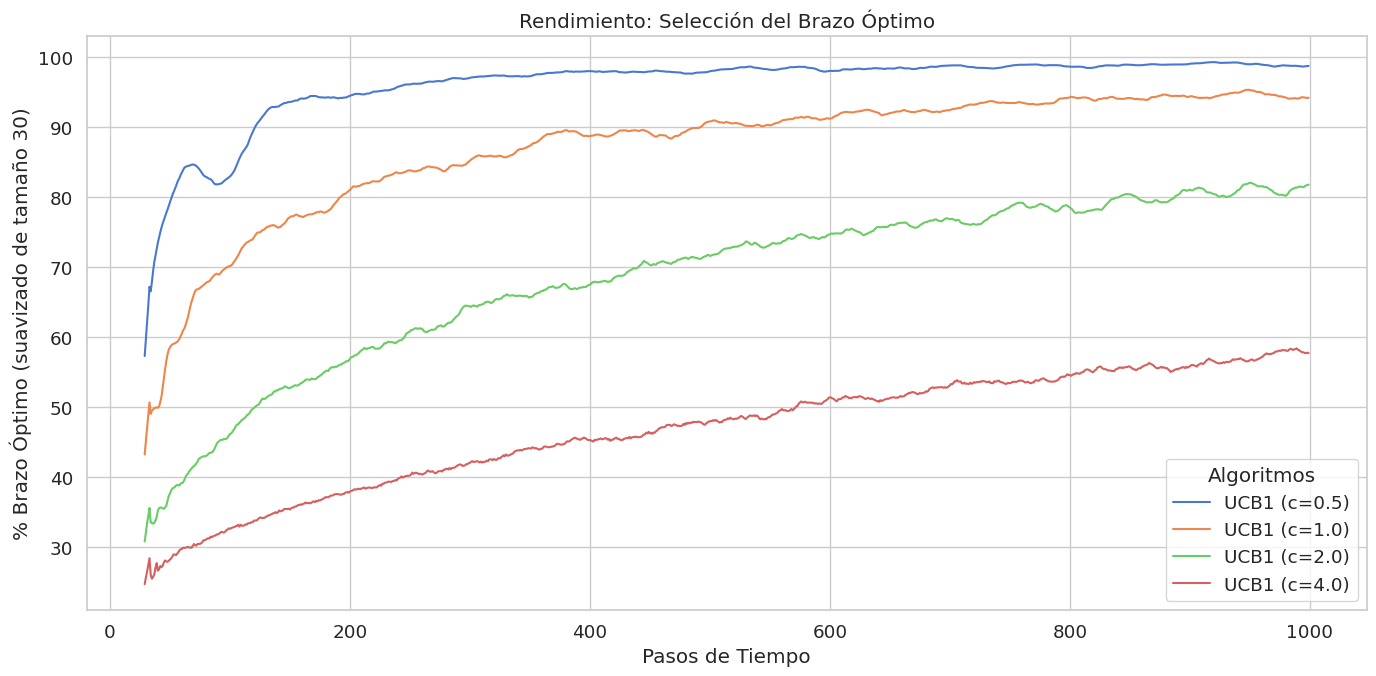

In [13]:
plot_optimal_selections(steps, optimal_selections_ucb, agents_ucb, window_size=30)

Véase como en $c=0.5$, la tasa de acierto en la selección de brazo óptimo es casi del 100%. Dado que el algoritmo siempre mantiene un término exploratorio, aunque la probabilidad de explorar es pequeña y se reduce con el tiempo, sigue existiendo, lo que impide estabilizar en el 100% de acierto siempre.

Calculamos el arrepentimiento acumulado y lo comparamos con la cota teórica de Lai-Robbins:

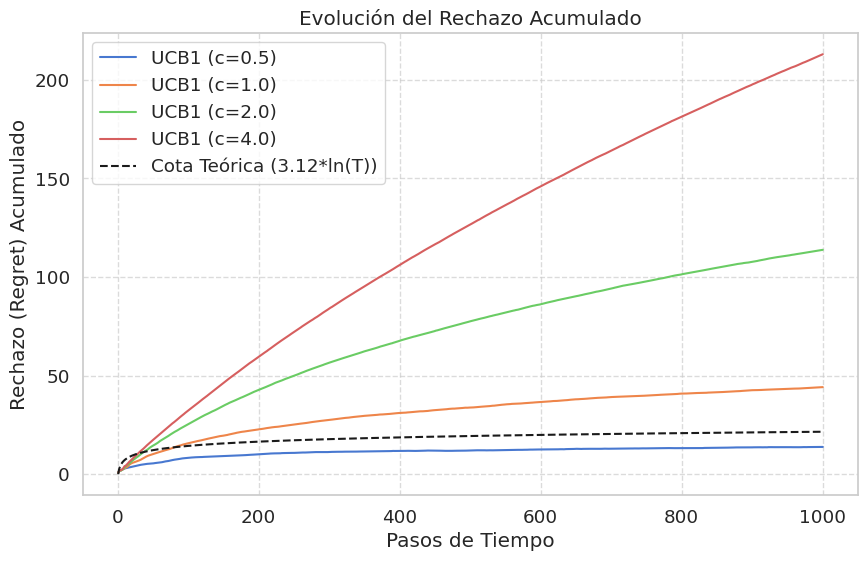

In [14]:
_, optimal_value = bandit.optimal_arm
regret_per_step = optimal_value - rewards_ucb
cumulative_regret = np.cumsum(regret_per_step, axis=1)

plot_regret(steps, cumulative_regret, agents_ucb, cte=lai_robbins_cte)

### Análisis de Resultados (UCB1)

1. **Estabilidad:** A diferencia de Epsilon-Greedy, UCB1 es mucho más estable y robusto. No requiere tanto ajuste de parámetros exhaustivo.
2. **Convergencia:** UCB1 logra identificar el brazo óptimo y, crucialmente, reduce la exploración con el tiempo. Esto se ve en la curva de regret, que crece de forma **logarítmica** (más lenta) en lugar de lineal.
3. **Impacto de c:** Valores muy altos de $c$ (ej. 4.0) provocan demasiada exploración inicial, pareciéndose a una búsqueda aleatoria al principio. Valores bajos convergen más rápido pero arriesgan subestimar brazos óptimos si tienen mala suerte al inicio.

---
## 6. Softmax con distintas temperaturas $\tau$
### Teoría: Softmax (Boltzmann Exploration)

El algoritmo **Softmax** elige brazos probabilísticamente, donde la probabilidad de elegir un brazo es proporcional a su valor estimado. Se usa la distribución de Boltzmann:

$$ P(a) = \frac{e^{Q_t(a)/\tau}}{\sum_{b=1}^k e^{Q_t(b)/\tau}} $$

- Si $\tau \to \infty$, las probabilidades tienden a ser uniformes (exploración pura).
- Si $\tau \to 0$, la probabilidad se concentra en el brazo con mayor valor (explotación pura / Greedy).

La ventaja sobre Epsilon-Greedy es que cuando explora, prefiere brazos "prometedores" (segundos mejores) sobre los claramente malos, en lugar de elegir cualquiera al azar.
El parámetro $\tau$ (temperatura) controla la distribución de probabilidad de selección:
- $\tau$ bajo: El agente es más decisivo (concentra la probabilidad en el brazo con mayor Q estimado).
- $\tau$ alto: Las probabilidades se igualan, generando exploración uniforme.

Comparamos:
- $\tau = 0.01$ (casi determinista)
- $\tau = 0.1$ (selectivo)
- $\tau = 0.5$ (moderado)
- $\tau = 1.0$ (más uniforme)

In [15]:
# Definir agentes Softmax con distinta temperatura
agents_soft = [
    SoftmaxAgent(k_arms=k, temperature=0.01),
    SoftmaxAgent(k_arms=k, temperature=0.1),
    SoftmaxAgent(k_arms=k, temperature=0.5),
    SoftmaxAgent(k_arms=k, temperature=1.0),
]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards_soft, optimal_selections_soft = run_experiment(bandit, agents_soft, steps, runs)

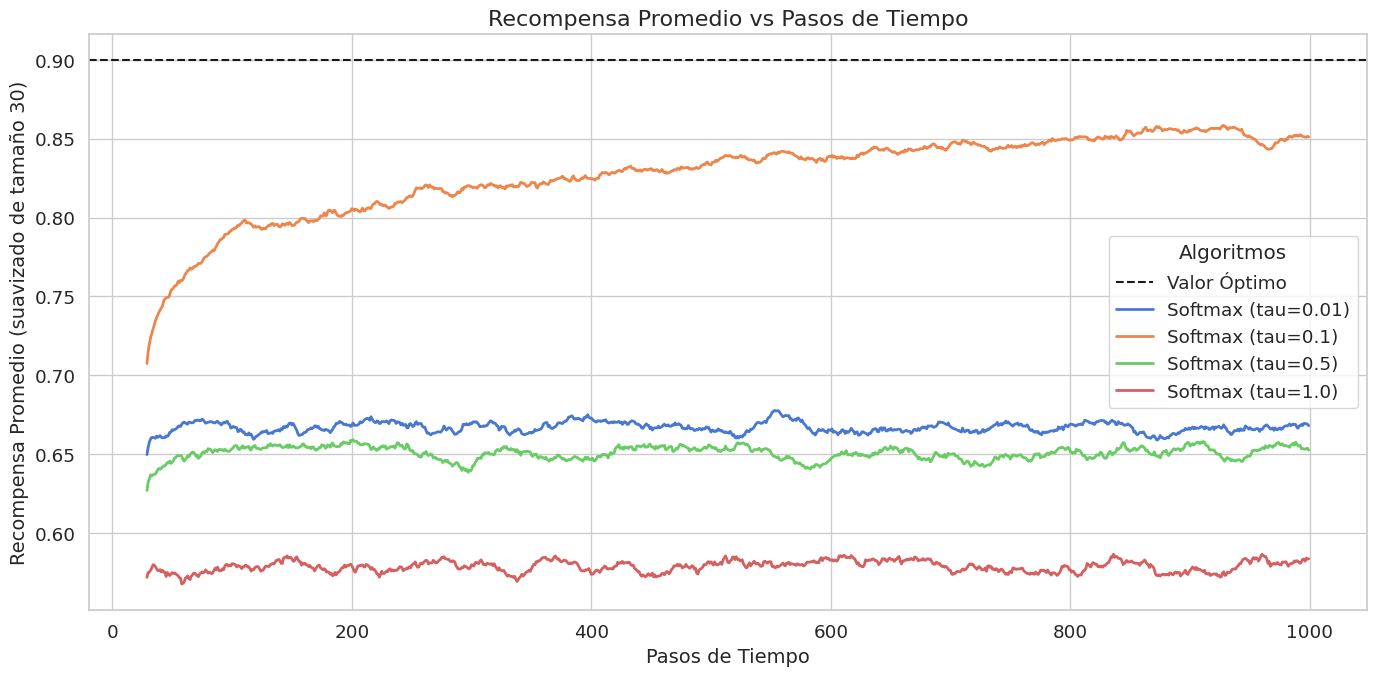

In [16]:
_, optimal_value = bandit.optimal_arm
plot_average_rewards(steps, rewards_soft, agents_soft, optimal_value=optimal_value, window_size=30)

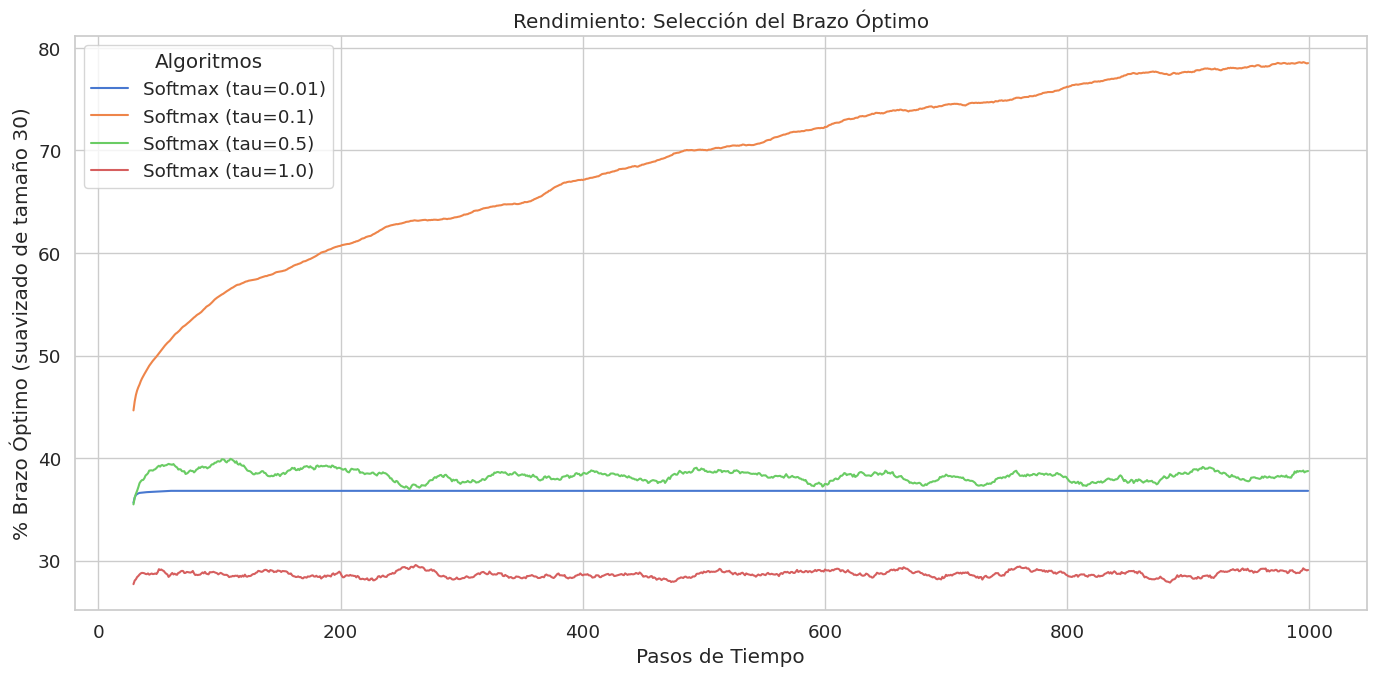

In [17]:
plot_optimal_selections(steps, optimal_selections_soft, agents_soft, window_size=30)

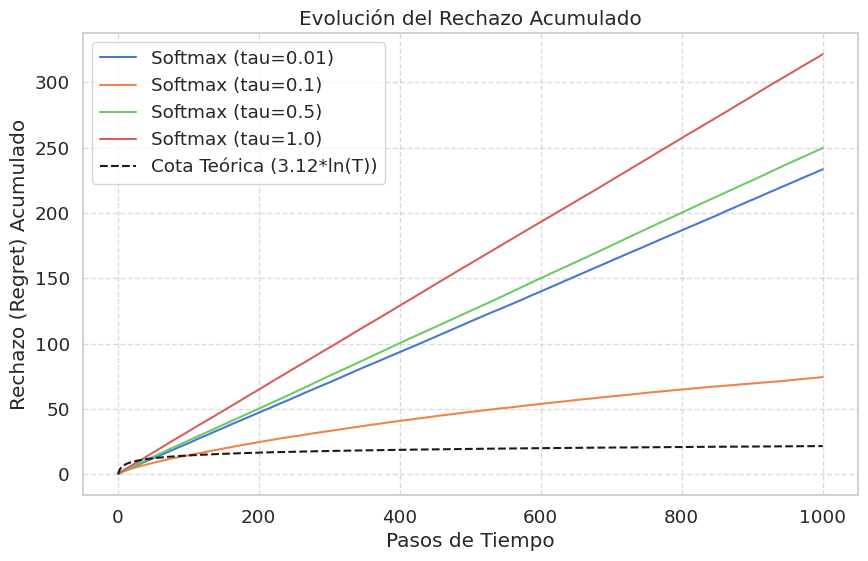

In [18]:
_, optimal_value = bandit.optimal_arm
regret_per_step = optimal_value - rewards_soft
cumulative_regret = np.cumsum(regret_per_step, axis=1)

plot_regret(steps, cumulative_regret, agents_soft, cte=lai_robbins_cte)

### Análisis de Resultados (Softmax)

1. **Sensibilidad a $\tau$:** Softmax es muy sensible al parámetro de temperatura. Un valor incorrecto puede degradar mucho el rendimiento.
2. **Comportamiento:** Con $\tau=0.1$, Softmax suele comportarse muy bien, superando a menudo a Epsilon-Greedy porque evita explorar brazos desastrosos. Es una estrategia más "inteligente" de exploración.
3. **Limitación:** Al igual que Epsilon-Greedy con $\epsilon$ constante, Softmax con $\tau$ constante no reduce su exploración a cero asintóticamente (a menos que $\tau$ se enfríe con el tiempo, lo cual no estamos haciendo aquí).

---
## 7. Comparación entre todos los algoritmos
### Comparación Directa

Ahora enfrentamos a los "campeones" de cada categoría. Esto nos permite ver qué estrategia domina bajo las mismas condiciones. Esperamos ver que UCB1 ofrezca el mejor equilibrio entre estabilidad y rendimiento a largo plazo.
Seleccionamos la mejor configuración de cada algoritmo y los enfrentamos en el mismo problema:
- **ε-Greedy** con ε = 0.1
- **UCB1** con c = 0.5
- **Softmax** con τ = 0.1

In [19]:
agents_comp = [
    EpsilonGreedyAgent(k, epsilon=0.1),
    UCBAgent(k, c=0.5),
    SoftmaxAgent(k, temperature=0.1),
]

rewards_comp, optimal_comp = run_experiment(bandit, agents_comp, steps=steps, runs=runs)

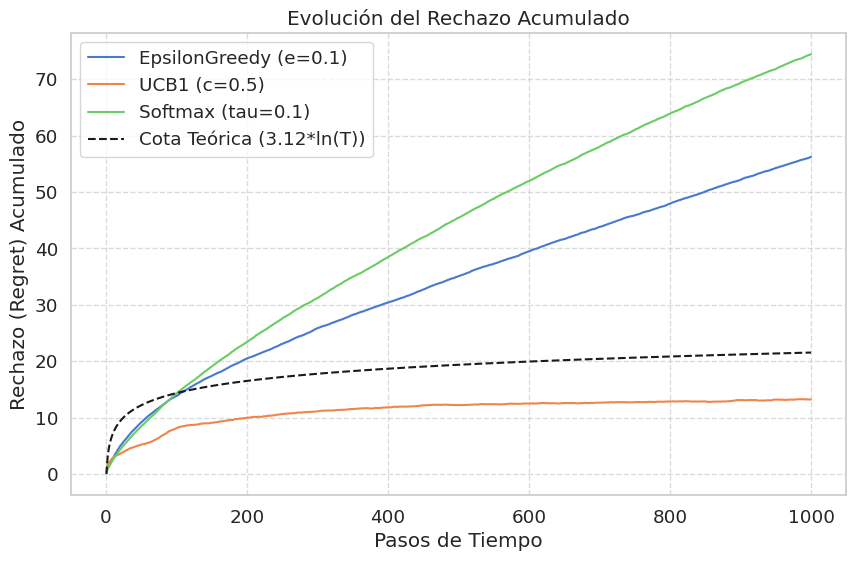

In [20]:
_, optimal_value = bandit.optimal_arm
regret_per_step = optimal_value - rewards_comp
cumulative_regret = np.cumsum(regret_per_step, axis=1)

plot_regret(steps, cumulative_regret, agents_comp, cte=lai_robbins_cte)

Véase como UCB1 es el que mejor se comporta respecto a las mejores versiones de los otros métodos.

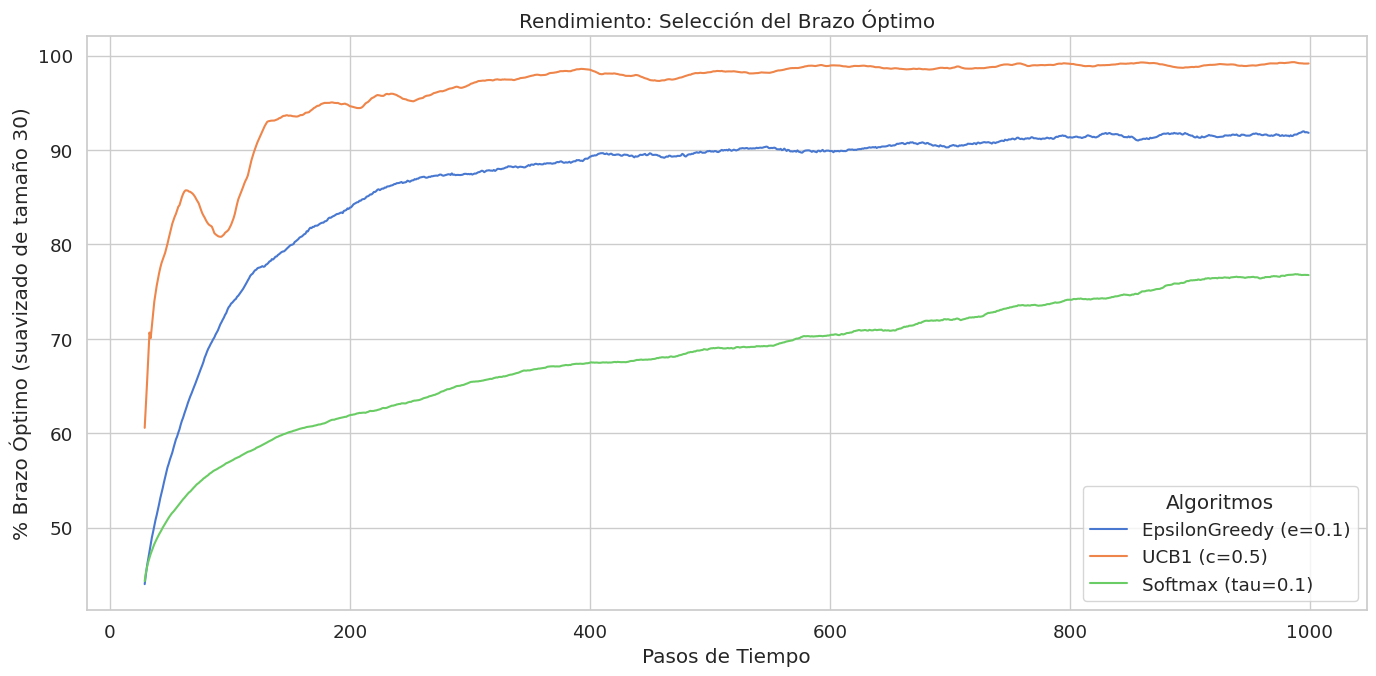

In [21]:
plot_optimal_selections(steps, optimal_comp, agents_comp, window_size=30)

UCB1 es el que mejor converge a una selección optima de forma consistente, softmax es más estable pero acrece de forma más lenta que el epsilon greedy.

### Análisis Comparativo

La gráfica anterior resume el rendimiento relativo. A continuación, mostramos los valores finales numéricos para una comparación precisa:

In [22]:
_, optimal_value = bandit.optimal_arm
print("{:<15} | {:<15} | {:<15}".format("Algoritmo", "Regret Final", "Selección Óptima %"))
print("-"*55)
for i, agent in enumerate(agents_comp):
    # Calcular regret final acumulado
    regret_final = np.sum(optimal_value - rewards_comp[i])
    print("{:<15} | {:<15.2f} | {:<15.2f}%".format(
        agent.name, 
        regret_final, 
        optimal_comp[i, -1] * 100
    ))

Algoritmo       | Regret Final    | Selección Óptima %
-------------------------------------------------------
EpsilonGreedy (e=0.1) | 56.22           | 90.20          %
UCB1 (c=0.5)    | 13.23           | 98.60          %
Softmax (tau=0.1) | 74.40           | 76.80          %


---
## 8. Estudio con brazos más cercanos entre sí
### Escenarios Difíciles

En la teoría de bandits, la dificultad de un problema depende de $\Delta_a = \mu^* - \mu_a$, la diferencia entre el brazo óptimo y los demás. Si $\Delta_a$ es muy pequeño, es estadísticamente difícil distinguir qué brazo es mejor, requiriendo más muestras (exploración) para tener confianza.

En este experimento, probamos con probabilidades muy cercanas: $[0.4, 0.42, 0.45, 0.48, 0.5]$.
Los problemas de bandit son más difíciles cuando los brazos tienen probabilidades similares.
Probamos con un conjunto de brazos donde las diferencias son pequeñas.

In [23]:
# Brazos con probabilidades cercanas (difícil de distinguir)
hard_bandit = Bandit(arms=[
    BernoulliArm(0.4),
    BernoulliArm(0.42),
    BernoulliArm(0.45),
    BernoulliArm(0.48),
    BernoulliArm(0.5),
])

hard_lai_robbins = hard_bandit.get_theoretical_constant()
show_bandit_info(hard_bandit, "Bandit Difícil (brazos cercanos)")

agents_hard = [
    EpsilonGreedyAgent(k, epsilon=0.1),
    UCBAgent(k, c=0.5),
    SoftmaxAgent(k, temperature=0.1),
]

# Aumentamos los pasos porque el problema es más difícil
hard_steps = 2000
hard_runs = 500
rewards_hard, optimal_hard = run_experiment(
    hard_bandit, agents_hard, hard_steps, hard_runs
)

--- Bandit Difícil (brazos cercanos) ---
Bandit with 5 arms: ArmBernoulli(p=0.4), ArmBernoulli(p=0.42), ArmBernoulli(p=0.45), ArmBernoulli(p=0.48), ArmBernoulli(p=0.5)
Brazo óptimo: 4 con media 0.5000
Constante de Lai-Robbins: 46.1661


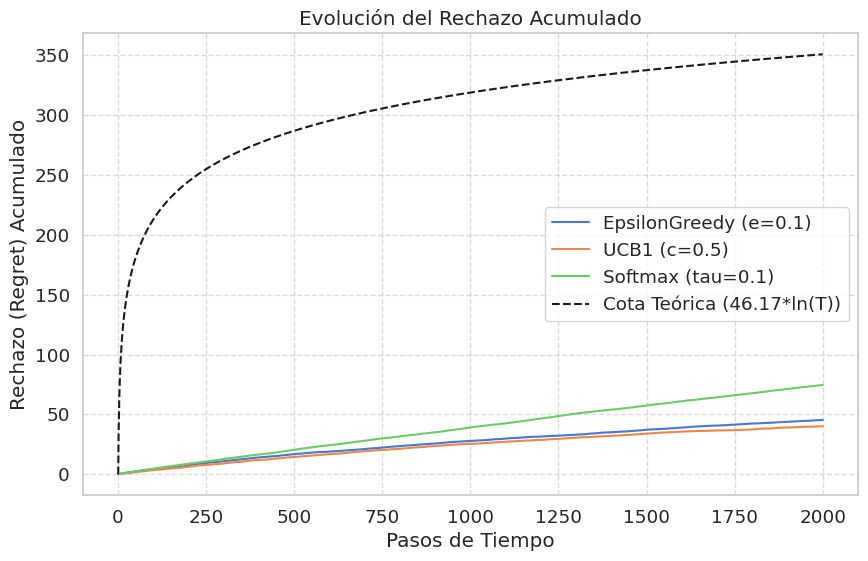

In [24]:
# Regret en problema difícil
_, optimal_value_hard = hard_bandit.optimal_arm
regret_per_step = optimal_value_hard - rewards_hard
cumulative_regret = np.cumsum(regret_per_step, axis=1)

plot_regret(hard_steps, cumulative_regret, agents_hard, cte=hard_lai_robbins)

Véase cómo softmax sufre más, acumulando más arrepentimiento, respecto a epsilon greedy, cuando la variación entre las recompensas es menor. Además, en este caso, UCB1 deja de ser tan efectivo y se emptata con epsilon greedy en esta métrica.

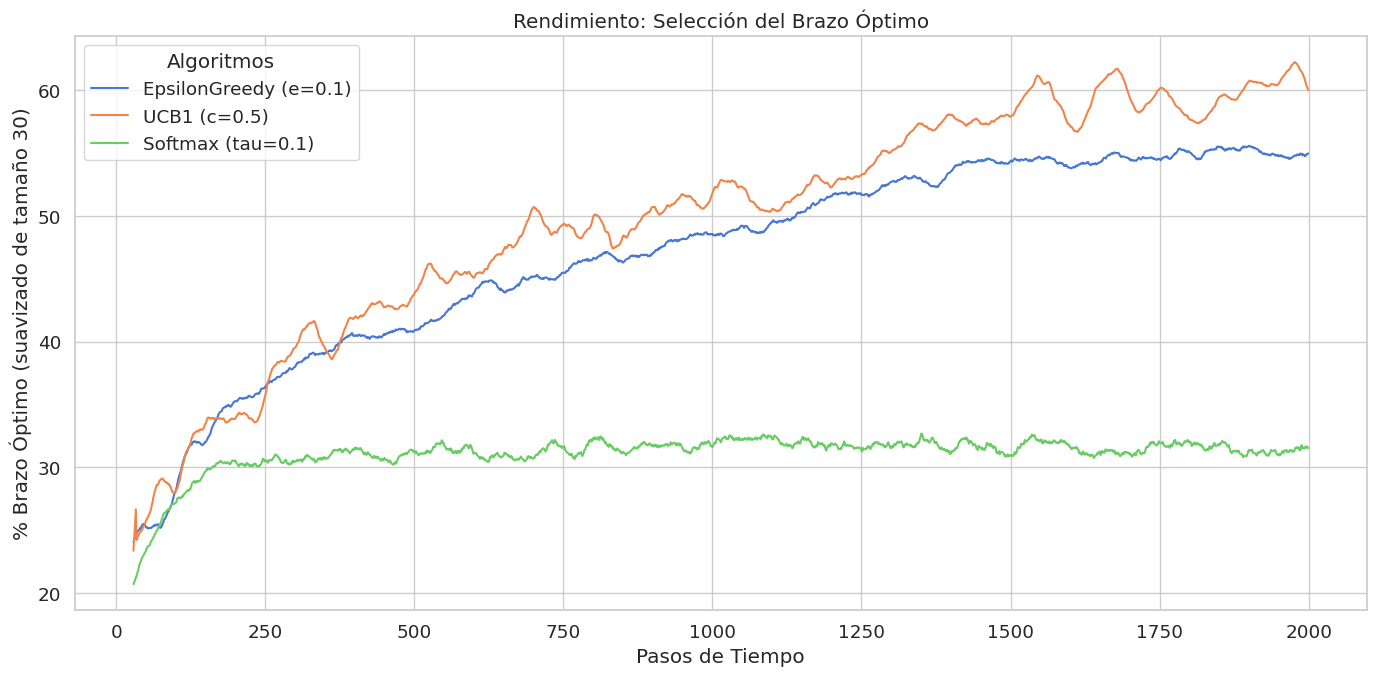

In [25]:
# Selección óptima en problema difícil
plot_optimal_selections(hard_steps, optimal_hard, agents_hard, window_size=30)

Aun así, véase como UCB1 mantiene marginalmente un porcentaje de elección del brazo optimo algo mayor que la de epsilon greedy.

---
## 9. Estudio con brazos generados automáticamente

Utilizamos el generador `BernoulliArm.generate_arms()` para crear
un bandido con 10 brazos distribuidos uniformemente en [0.1, 0.95].

In [26]:
# Generar 10 brazos con probabilidades uniformemente espaciadas
auto_bandit = Bandit(arms=BernoulliArm.generate_arms(k=10, min_p=0.1, max_p=0.95))
k_auto = len(auto_bandit.arms)
auto_lai_robbins = auto_bandit.get_theoretical_constant()
show_bandit_info(auto_bandit, "Bandit Auto-generado (10 brazos)")

agents_auto = [
    EpsilonGreedyAgent(k_auto, epsilon=0.1),
    UCBAgent(k_auto, c=0.5),
    SoftmaxAgent(k_auto, temperature=0.1),
]

auto_steps = 2000
auto_runs = 500
rewards_auto, optimal_auto = run_experiment(
    auto_bandit, agents_auto, auto_steps, auto_runs
)

--- Bandit Auto-generado (10 brazos) ---
Bandit with 10 arms: ArmBernoulli(p=0.1), ArmBernoulli(p=0.19444444444444445), ArmBernoulli(p=0.28888888888888886), ArmBernoulli(p=0.3833333333333333), ArmBernoulli(p=0.47777777777777775), ArmBernoulli(p=0.5722222222222222), ArmBernoulli(p=0.6666666666666666), ArmBernoulli(p=0.7611111111111111), ArmBernoulli(p=0.8555555555555555), ArmBernoulli(p=0.95)
Brazo óptimo: 9 con media 0.9500
Constante de Lai-Robbins: 5.8976


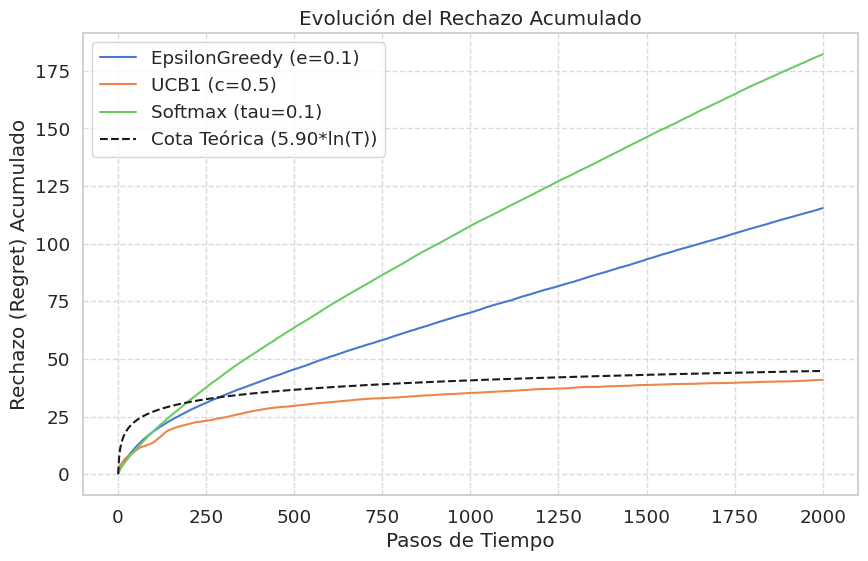

In [27]:
# Regret acumulado con 10 brazos
_, optimal_value_auto = auto_bandit.optimal_arm
regret_per_step = optimal_value_auto - rewards_auto
cumulative_regret = np.cumsum(regret_per_step, axis=1)

plot_regret(auto_steps, cumulative_regret, agents_auto, cte=auto_lai_robbins)

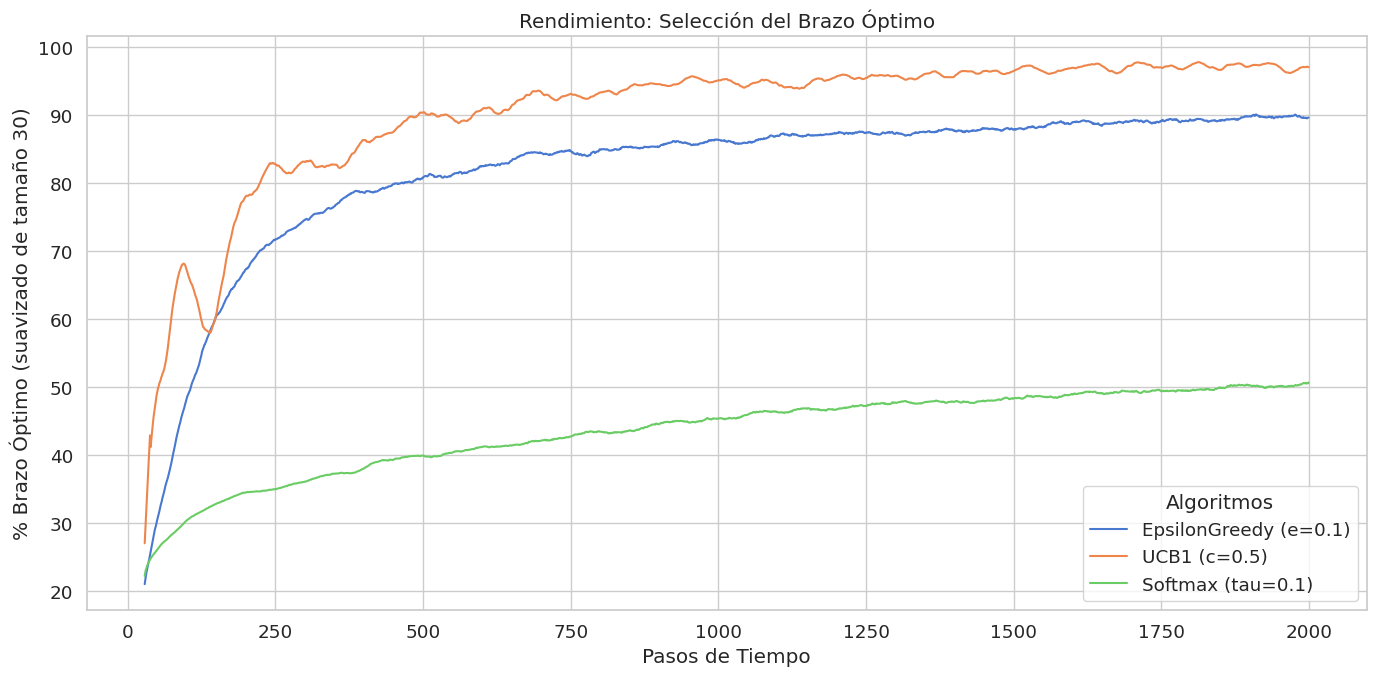

In [28]:
# Selección óptima con 10 brazos
plot_optimal_selections(auto_steps, optimal_auto, agents_auto, window_size=30)

## 10. Epsilon-Decay vs Epsilon-Greedy

Analizamos el rendimiento del `EpsilonDecayAgent` en comparación con `EpsilonGreedyAgent` en el entorno Bernoulli.

In [29]:
agents_decay = [
    EpsilonGreedyAgent(k, epsilon=0.1),
    EpsilonDecayAgent(k, e_start=1.0, e_end=0.01, lda=0.01),
    EpsilonDecayAgent(k, e_start=1.0, e_end=0.01, lda=0.05),
    EpsilonDecayAgent(k, e_start=1.0, e_end=0.01, lda=0.1)
]

decay_steps = 2000
decay_runs = 500
rewards_decay, optimal_decay = run_experiment(
    bandit, agents_decay, decay_steps, decay_runs
)

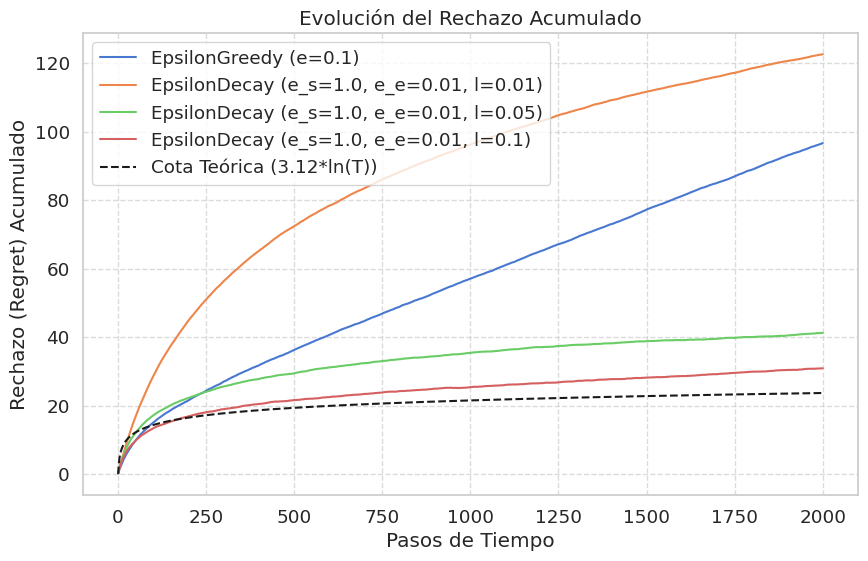

In [30]:
# Gráfica de regret acumulado para Epsilon-Decay
_, optimal_value = bandit.optimal_arm
regret_per_step = optimal_value - rewards_decay
cumulative_regret = np.cumsum(regret_per_step, axis=1)

plot_regret(decay_steps, cumulative_regret, agents_decay, cte=lai_robbins_cte)

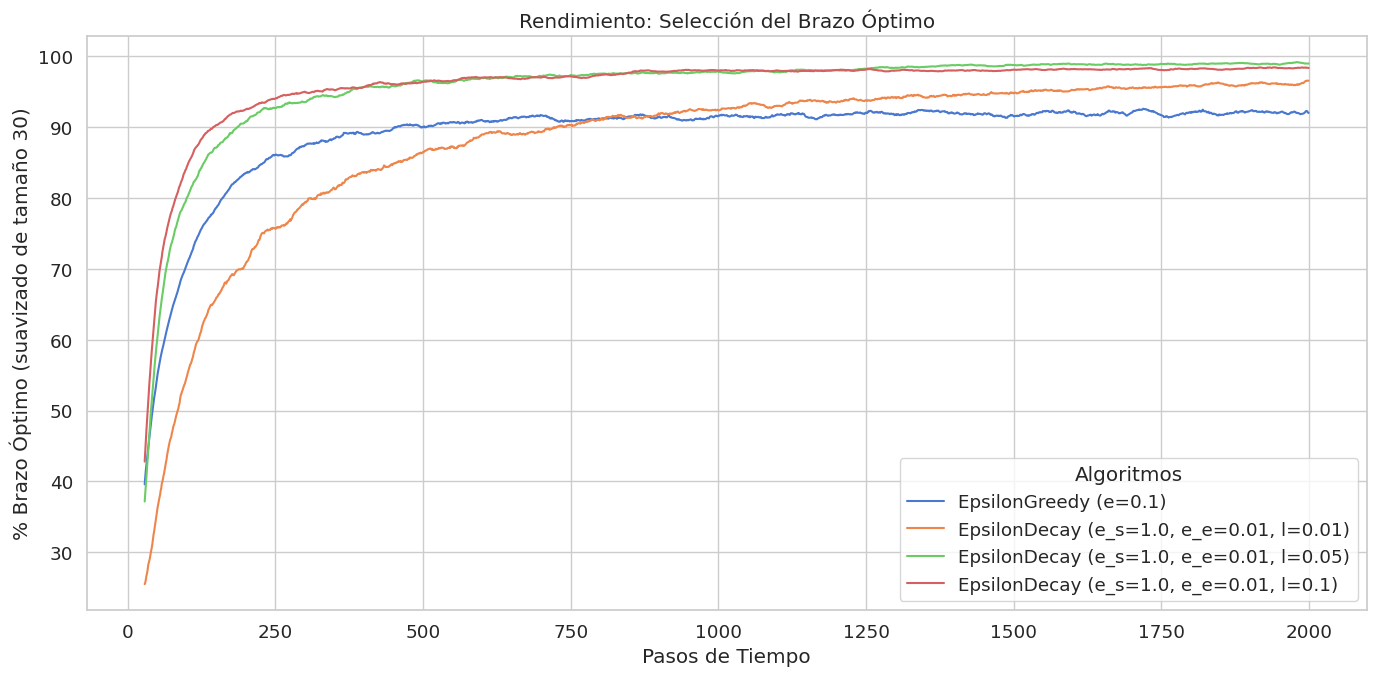

In [31]:
# Gráfica de porcentaje de selección óptima
plot_optimal_selections(decay_steps, optimal_decay, agents_decay, window_size=30)